# Alternative: Conditional Diffusion with Macro Features

This notebook tests the macro-augmented conditional diffusion pipeline end-to-end.
It:
1. Computes the 4 CRSP-derived macro features from the return panel
2. Builds training and validation covariance datasets with macro conditioning (55+4 = 59 dims)
3. Fits new scalers on the augmented training conditioning vectors
4. Trains a macro-conditioned DDPM (T=400, 50 epochs) and a baseline DDPM (no macro) side-by-side
5. Compares training loss curves
6. Generates conditional covariance scenarios for a sample validation sleeve
7. Visualises macro feature time series and their regime signal

**Conditioning vector layout:**
```
c̃ = [vech(logm(S_hist + εI))  (55 dims)  |  macro features (K dims)]
```
With CRSP-only features: K=4, total=59.  
With FRED data (run `scripts/00_download_macro_data.py` first): K=7, total=62.

**Research basis for each macro feature** is documented in `src/macro_features.py`.

In [3]:
import sys, os, warnings, logging
from pathlib import Path

# Make src/ importable from repo root
ROOT = Path(".").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

warnings.filterwarnings("ignore", category=FutureWarning)
logging.basicConfig(level=logging.WARNING)   # suppress verbose src/ logs
logging.getLogger("src").setLevel(logging.INFO)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import torch

plt.rcParams.update({"figure.dpi": 110, "font.size": 11})
print(f"PyTorch {torch.__version__}  |  CUDA={torch.cuda.is_available()}  |  MPS={torch.backends.mps.is_available()}")

PyTorch 2.11.0  |  CUDA=False  |  MPS=True


## 1. Load Existing Interim Data

Scripts 01–03 must have been run before this notebook.  
We load the already-cleaned CRSP panel and the pre-built training-group membership.

In [4]:
# ── Paths ────────────────────────────────────────────────────────────────────
INTERIM       = ROOT / "data" / "interim"
PROCESSED     = ROOT / "data" / "processed"
SCALER_DIR    = ROOT / "artifacts" / "scalers"
MODEL_DIR     = ROOT / "artifacts" / "models"
LOG_DIR       = ROOT / "artifacts" / "training_logs"
MACRO_CACHE   = INTERIM / "macro_features.parquet"
MACRO_EXT     = INTERIM / "macro_external.parquet"

# Alternative artefacts go here so they don't overwrite the main-pipeline ones
ALT_SCALER_DIR = ROOT / "artifacts" / "scalers_macro"
ALT_MODEL_DIR  = ROOT / "artifacts" / "models_macro"
ALT_LOG_DIR    = ROOT / "artifacts" / "training_logs_macro"
for d in [ALT_SCALER_DIR, ALT_MODEL_DIR, ALT_LOG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── Load CRSP panel ───────────────────────────────────────────────────────────
print("Loading cleaned CRSP panel …")
crsp_df = pd.read_parquet(INTERIM / "cleaned_crsp_daily.parquet")
crsp_df["date"] = pd.to_datetime(crsp_df["date"])
print(f"  Rows: {len(crsp_df):,}  |  cols: {list(crsp_df.columns)}")
print(f"  Date range: {crsp_df['date'].min().date()} – {crsp_df['date'].max().date()}")

Loading cleaned CRSP panel …
  Rows: 30,703,331  |  cols: ['date', 'permno', 'ret_total', 'me', 'shrcd', 'exchcd', 'siccd']
  Date range: 1998-01-02 – 2024-12-31


In [5]:
# ── Trading calendar and training groups ──────────────────────────────────────
trading_calendar = pd.read_parquet(INTERIM / "trading_calendar.parquet")
trading_dates    = pd.DatetimeIndex(pd.to_datetime(trading_calendar.iloc[:, 0]))
print(f"Trading calendar: {len(trading_dates)} dates, "
      f"{trading_dates.min().date()} – {trading_dates.max().date()}")

training_groups = pd.read_parquet(INTERIM / "training_groups.parquet")
print(f"Training groups: {len(training_groups):,} rows, "
      f"{training_groups['group_id'].nunique()} unique groups")

eval_sleeves = pd.read_parquet(INTERIM / "evaluation_sleeves.parquet")
print(f"Evaluation sleeves: {len(eval_sleeves):,} rows")

Trading calendar: 6793 dates, 1998-01-02 – 2024-12-31
Training groups: 49,730 rows, 4973 unique groups
Evaluation sleeves: 39,450 rows


## 2. Compute CRSP-Derived Macro Features

Four features are computed from the CRSP return panel at every viable trading date:

| Feature | Window | Research basis |
|---|---|---|
| `log_mkt_var_21d` | Short-horizon EW realized variance (log) | Andersen et al. (2003), Shephard & Sheppard (2010) |
| `log_mkt_var_126d` | Long-horizon EW realized variance (log) | Corsi (2009) HAR-RV, Ding et al. (1993) |
| `mkt_ret_21d` | Cumulative EW market return, 21 days | Black (1976) leverage effect, Engle & Ng (1993) |
| `avg_pairwise_corr_126d` | Implied equicorrelation over 126 days | Pollet & Wilson (2010 JF), Driessen et al. (2012 RFS) |

In [6]:
from src.macro_features import (
    build_macro_feature_df,
    get_macro_vector,
    save_macro_feature_names,
    load_macro_feature_names,
    CRSP_MACRO_FEATURES,
    ALL_MACRO_FEATURES,
)

if MACRO_CACHE.exists():
    print(f"Loading cached macro features from {MACRO_CACHE}")
    macro_df = pd.read_parquet(MACRO_CACHE)
    macro_df.index = pd.to_datetime(macro_df.index)
else:
    print("Computing macro features from CRSP panel (first run, ~2–5 min) …")
    external_path = MACRO_EXT if MACRO_EXT.exists() else None
    macro_df = build_macro_feature_df(
        crsp_df=crsp_df,
        trading_dates=trading_dates,
        external_path=external_path,
        lookback_short=21,
        lookback_long=126,
        min_stocks_corr=20,
    )
    macro_df.to_parquet(MACRO_CACHE)
    print(f"  Saved → {MACRO_CACHE}")

K = macro_df.shape[1]
print(f"\nMacro features: {list(macro_df.columns)}")
print(f"K = {K}  →  condition_dim = 55 + {K} = {55 + K}")
print(f"Date range: {macro_df.index.min().date()} – {macro_df.index.max().date()}")
macro_df.describe().round(4)

Loading cached macro features from /Users/brianrhie/Documents/Quant/Find-A/Final/data/interim/macro_features.parquet

Macro features: ['log_mkt_var_21d', 'log_mkt_var_126d', 'mkt_ret_21d', 'avg_pairwise_corr_126d']
K = 4  →  condition_dim = 55 + 4 = 59
Date range: 1998-02-02 – 2024-12-31


,log_mkt_var_21d,log_mkt_var_126d,mkt_ret_21d,avg_pairwise_corr_126d
count,6773.0000,6668.0000,6773.0000,6667.0000
mean,-9.3330,-9.1296,0.0143,0.0706
std,0.9188,0.7546,0.0676,0.0439
min,-12.2054,-10.5162,-0.3977,0.0103
25%,-9.9915,-9.6625,-0.0235,0.0438
50%,-9.4301,-9.2182,0.0168,0.0606
75%,-8.7922,-8.7149,0.0505,0.0827
max,-5.4754,-6.7474,0.4094,0.2618


## 3. Visualise Macro Features

Check the time-series signal content before conditioning on them.

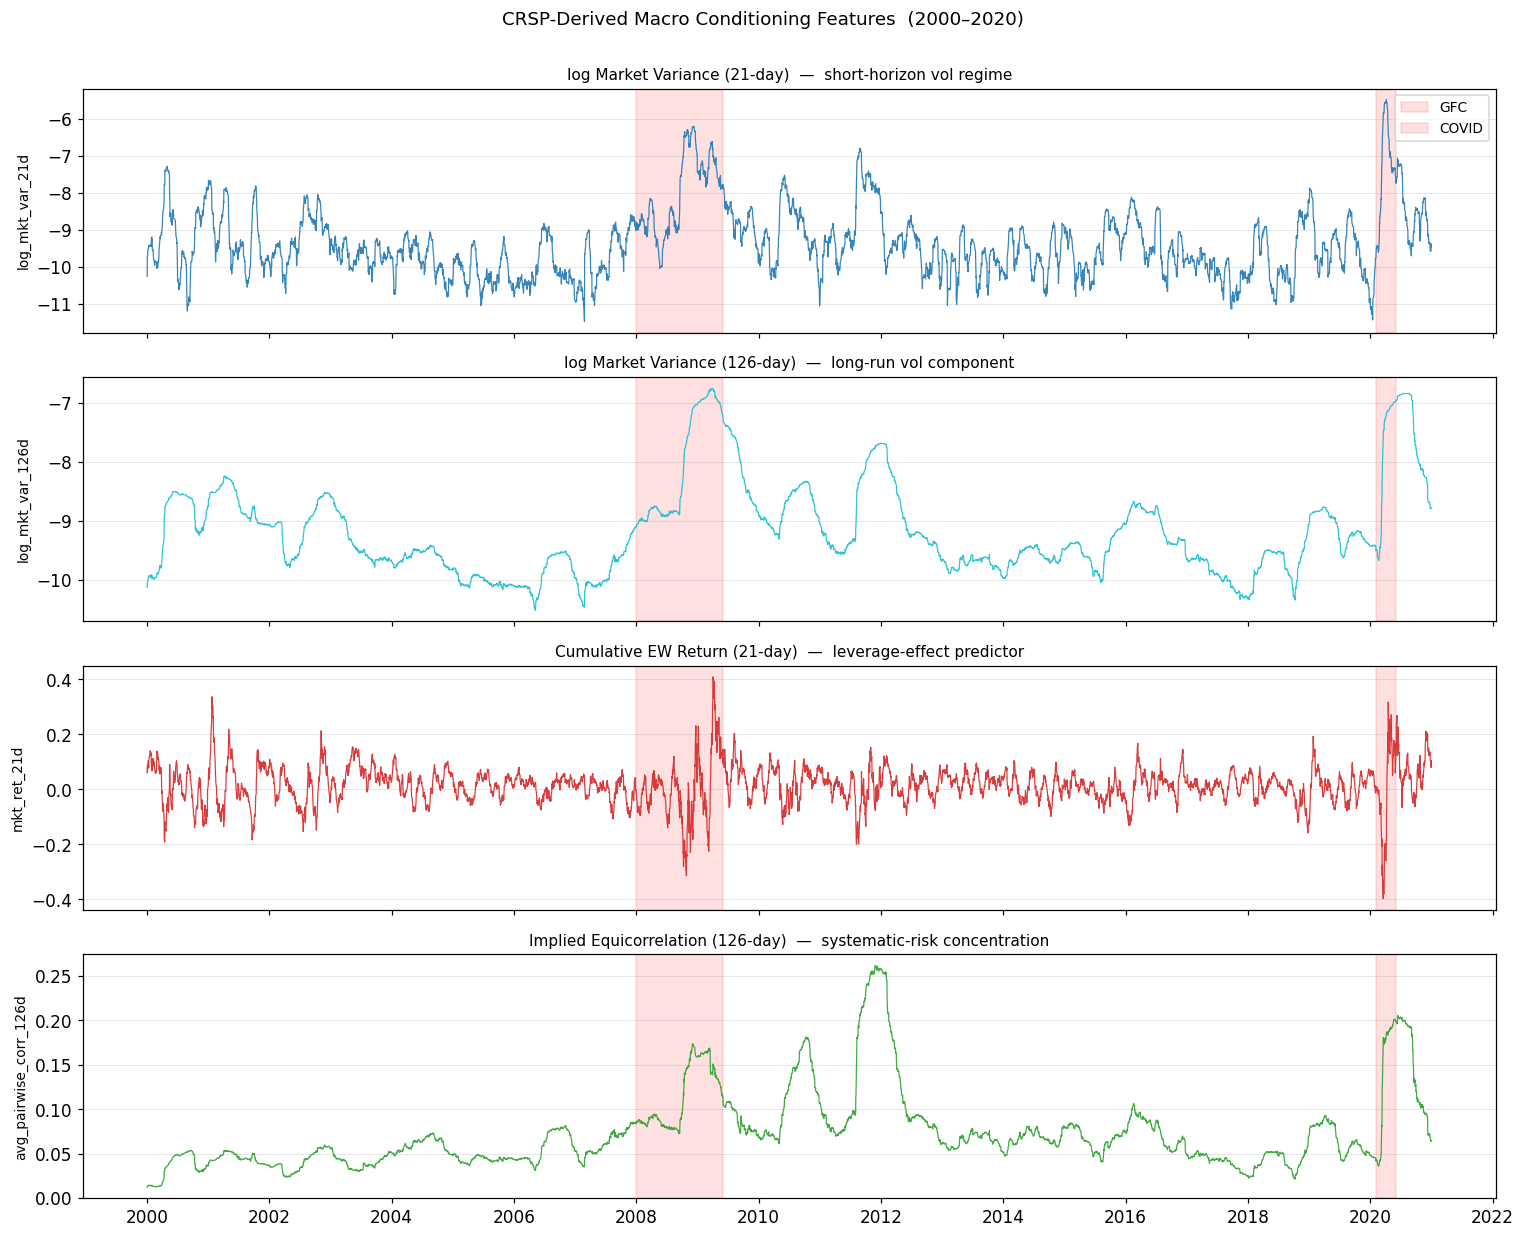

In [7]:
fig, axes = plt.subplots(K, 1, figsize=(14, 2.8 * K), sharex=True)
if K == 1:
    axes = [axes]

# Restrict to training + validation window for interpretability
plot_macro = macro_df.loc["2000-01-01":"2020-12-31"]

titles = {
    "log_mkt_var_21d":        "log Market Variance (21-day)  —  short-horizon vol regime",
    "log_mkt_var_126d":       "log Market Variance (126-day)  —  long-run vol component",
    "mkt_ret_21d":            "Cumulative EW Return (21-day)  —  leverage-effect predictor",
    "avg_pairwise_corr_126d": "Implied Equicorrelation (126-day)  —  systematic-risk concentration",
    "log_vix":                "log VIX  —  market-implied variance expectation",
    "term_spread":            "Term Spread (10Y − 2Y)  —  recession signal",
    "credit_spread":          "IG Credit OAS  —  financial-distress signal",
}

colors = ["#1f77b4", "#17becf", "#d62728", "#2ca02c", "#9467bd", "#ff7f0e", "#8c564b"]

for ax, col, color in zip(axes, macro_df.columns, colors):
    ax.plot(plot_macro.index, plot_macro[col], lw=0.8, color=color, alpha=0.9)
    ax.set_ylabel(col, fontsize=9)
    ax.set_title(titles.get(col, col), fontsize=10)
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    # Shade the GFC and COVID stress periods
    for shade_start, shade_end, label in [
        ("2008-01", "2009-06", "GFC"),
        ("2020-02", "2020-06", "COVID"),
    ]:
        ax.axvspan(pd.Timestamp(shade_start), pd.Timestamp(shade_end),
                   alpha=0.12, color="red", label=label if col == macro_df.columns[0] else "_")
    ax.grid(axis="y", lw=0.4, alpha=0.5)

axes[0].legend(loc="upper right", fontsize=9)
fig.suptitle("CRSP-Derived Macro Conditioning Features  (2000–2020)", fontsize=12, y=1.002)
fig.tight_layout()
plt.savefig(ROOT / "results" / "figures" / "macro_features_time_series.png",
            bbox_inches="tight", dpi=130)
plt.show()

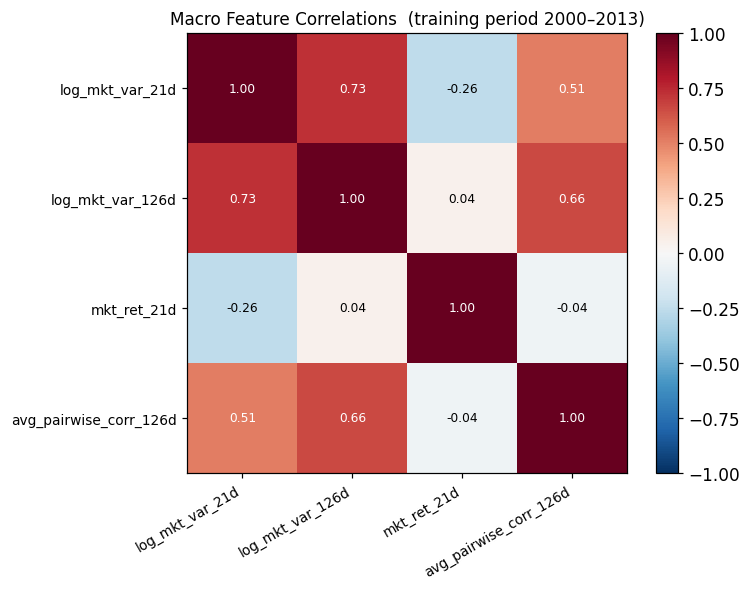

In [8]:
# Correlation matrix of macro features (training period only)
train_macro = macro_df.loc["2000-01-01":"2013-12-31"].dropna()
corr_mat = train_macro.corr()

fig, ax = plt.subplots(figsize=(7, 5.5))
im = ax.imshow(corr_mat, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(K))
ax.set_yticks(range(K))
ax.set_xticklabels(macro_df.columns, rotation=30, ha="right", fontsize=9)
ax.set_yticklabels(macro_df.columns, fontsize=9)
for i in range(K):
    for j in range(K):
        ax.text(j, i, f"{corr_mat.iloc[i, j]:.2f}",
                ha="center", va="center", fontsize=8,
                color="white" if abs(corr_mat.iloc[i, j]) > 0.5 else "black")
plt.colorbar(im, ax=ax)
ax.set_title("Macro Feature Correlations  (training period 2000–2013)", fontsize=11)
fig.tight_layout()
plt.savefig(ROOT / "results" / "figures" / "macro_feature_correlations.png",
            bbox_inches="tight", dpi=130)
plt.show()

## 4. Build Macro-Augmented Covariance Datasets

The training dataset is built using a daily-sliding window (stride=1) over training groups.  
Macro features for each anchor date are appended to the 55-dim log-vech, giving a **(n, 59)** conditioning matrix.

To keep the notebook fast we build a **small sample** (first 300 training groups) and the **full validation set**.  
For production, replace `sample_groups` with the full `training_groups`.

In [9]:
from src.datasets import (
    build_daily_sliding_covariance_dataset,
    build_covariance_dataset,
    apply_scalers,
)
from src.transforms import fit_training_scalers, load_scalers

TRAIN_END = pd.Timestamp("2013-12-31")
SAMPLE_GROUPS = 300    # ← increase to use all groups (slower)

# Subsample for speed — keep deterministic ordering
sample_gids = sorted(training_groups["group_id"].unique())[:SAMPLE_GROUPS]
sample_groups_df = training_groups[training_groups["group_id"].isin(sample_gids)]
print(f"Using {len(sample_gids)} training groups  "
      f"({len(sample_groups_df):,} membership rows)")

Using 300 training groups  (3,000 membership rows)


In [10]:
%%time
print("Building MACRO-AUGMENTED training dataset (daily-sliding, stride=1) …")
train_ds_macro = build_daily_sliding_covariance_dataset(
    crsp_df=crsp_df,
    trading_dates=trading_dates,
    groups_df=sample_groups_df,
    train_end_date=TRAIN_END,
    lookback_days=126,
    horizon_days=21,
    ridge_epsilon=1e-8,
    stride=1,
    macro_df=macro_df,          # ← inject macro features
)
print(f"\nMacro training set:")
print(f"  condition_vech : {train_ds_macro['condition_vech'].shape}  ← (n, 55+K)")
print(f"  target_vech    : {train_ds_macro['target_vech'].shape}")

INFO:src.datasets:Building daily-sliding training dataset: 300 groups, stride=1 …


Building MACRO-AUGMENTED training dataset (daily-sliding, stride=1) …


INFO:src.datasets:Daily-sliding dataset: 5522 pairs built, 778 anchor dates skipped (missing returns or boundary).
INFO:src.datasets:Sliding training pairs: 5522 | cond (5522, 59) | tgt (5522, 55)



Macro training set:
  condition_vech : (5522, 59)  ← (n, 55+K)
  target_vech    : (5522, 55)
CPU times: user 1min 49s, sys: 52.2 s, total: 2min 41s
Wall time: 56.4 s


In [11]:
%%time
print("Building BASELINE training dataset (no macro) …")
train_ds_base = build_daily_sliding_covariance_dataset(
    crsp_df=crsp_df,
    trading_dates=trading_dates,
    groups_df=sample_groups_df,
    train_end_date=TRAIN_END,
    lookback_days=126,
    horizon_days=21,
    ridge_epsilon=1e-8,
    stride=1,
    macro_df=None,              # ← no macro
)
print(f"\nBaseline training set:")
print(f"  condition_vech : {train_ds_base['condition_vech'].shape}  ← (n, 55)")
print(f"  target_vech    : {train_ds_base['target_vech'].shape}")

INFO:src.datasets:Building daily-sliding training dataset: 300 groups, stride=1 …


Building BASELINE training dataset (no macro) …


INFO:src.datasets:Daily-sliding dataset: 5522 pairs built, 778 anchor dates skipped (missing returns or boundary).
INFO:src.datasets:Sliding training pairs: 5522 | cond (5522, 55) | tgt (5522, 55)



Baseline training set:
  condition_vech : (5522, 55)  ← (n, 55)
  target_vech    : (5522, 55)
CPU times: user 2min 3s, sys: 56 s, total: 2min 59s
Wall time: 58.3 s


## 5. Fit Scalers and Apply to Both Datasets

The macro scalers are fitted on the **(n, 59)** training conditioning matrix — jointly across the covariance vech and macro feature columns.  StandardScaler operates per-column so scale differences do not cause issues.

In [26]:
from src.macro_features import save_macro_feature_names

# ── Macro scalers ────────────────────────────────────────────────────────────
print("Fitting MACRO scalers on training data …")
cond_scaler_macro, tgt_scaler_macro = fit_training_scalers(
    train_condition_vectors=train_ds_macro["condition_vech"],
    train_target_vectors=train_ds_macro["target_vech"],
    save_dir=ALT_SCALER_DIR,
)
save_macro_feature_names(list(macro_df.columns), ALT_SCALER_DIR)
train_ds_macro = apply_scalers(train_ds_macro, cond_scaler_macro, tgt_scaler_macro)
print(f"  condition_scaled shape: {train_ds_macro['condition_scaled'].shape}")

# ── Baseline scalers ─────────────────────────────────────────────────────────
print("\nFitting BASELINE scalers on training data …")
cond_scaler_base, tgt_scaler_base = fit_training_scalers(
    train_condition_vectors=train_ds_base["condition_vech"],
    train_target_vectors=train_ds_base["target_vech"],
    save_dir=None,
)
train_ds_base = apply_scalers(train_ds_base, cond_scaler_base, tgt_scaler_base)
print(f"  condition_scaled shape: {train_ds_base['condition_scaled'].shape}")

INFO:src.transforms:Scalers saved to /Users/brianrhie/Documents/Quant/Find-A/Final/artifacts/scalers_macro
INFO:src.macro_features:Saved macro feature names → /Users/brianrhie/Documents/Quant/Find-A/Final/artifacts/scalers_macro/macro_feature_names.json


Fitting MACRO scalers on training data …
  condition_scaled shape: (5522, 59)

Fitting BASELINE scalers on training data …
  condition_scaled shape: (5522, 55)


### Scaling sanity check

Each column of the scaled conditioning matrix should have mean ≈ 0, std ≈ 1 (on training data).

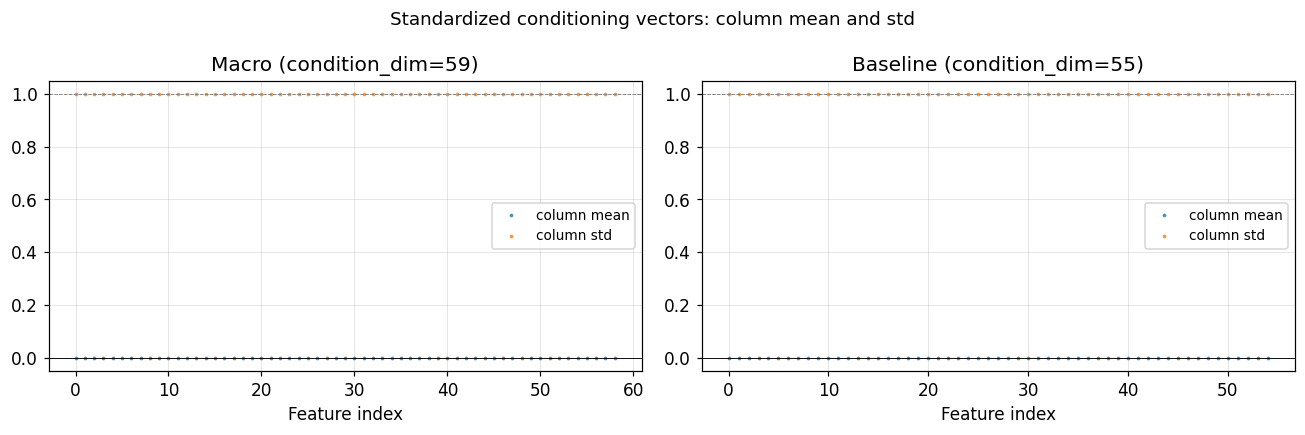

Macro   conditioning: mean range [-0.0000, 0.0000], std range [1.0000, 1.0000]


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (ds, label) in zip(axes, [
    (train_ds_macro, f"Macro (condition_dim=59)"),
    (train_ds_base,  "Baseline (condition_dim=55)"),
]):
    scaled = ds["condition_scaled"]
    col_means = scaled.mean(axis=0)
    col_stds  = scaled.std(axis=0)
    ax.plot(col_means, ".", ms=3, label="column mean", alpha=0.7)
    ax.plot(col_stds,  ".", ms=3, label="column std",  alpha=0.7)
    ax.axhline(0, color="k", lw=0.6)
    ax.axhline(1, color="gray", lw=0.6, ls="--")
    ax.set_xlabel("Feature index")
    ax.set_title(label)
    ax.legend(fontsize=9)
    ax.grid(lw=0.4, alpha=0.5)

fig.suptitle("Standardized conditioning vectors: column mean and std", fontsize=12)
fig.tight_layout()
plt.show()

print(f"Macro   conditioning: mean range [{col_means.min():.4f}, {col_means.max():.4f}], "
      f"std range [{train_ds_macro['condition_scaled'].std(axis=0).min():.4f}, "
      f"{train_ds_macro['condition_scaled'].std(axis=0).max():.4f}]")

## 6. Build Validation Sleeves for Both Pipelines

Validation uses deterministic non-overlapping evaluation sleeves (stride=21).

In [14]:
# evaluation_sleeves.parquet has no 'split' column — filter by rebalance_date.
# Validation: holding windows fall entirely in 2014-01-01 to 2020-12-31.
# The rebalance_date (last day of the 126-day lookback) for the first validation
# holding period is 2013-12-31; for the last it is before 2021-01-01.
# The ID column in evaluation_sleeves is 'sleeve_id', not 'group_id'.
eval_sleeves["rebalance_date"] = pd.to_datetime(eval_sleeves["rebalance_date"])

val_sleeves_df = eval_sleeves[
    (eval_sleeves["rebalance_date"] >= pd.Timestamp("2013-12-31")) &
    (eval_sleeves["rebalance_date"] <  pd.Timestamp("2021-01-01"))
]
print(f"Validation sleeves: {val_sleeves_df['sleeve_id'].nunique()} unique sleeves, "
      f"{val_sleeves_df['rebalance_date'].nunique()} rebalance dates")

# Use first 50 sleeves for the demo to keep generation fast
VAL_SAMPLE_GIDS = sorted(val_sleeves_df["sleeve_id"].unique())[:50]
val_sample_df   = val_sleeves_df[val_sleeves_df["sleeve_id"].isin(VAL_SAMPLE_GIDS)]

print("Building validation covariance dataset WITH macro …")
val_ds_macro = build_covariance_dataset(
    crsp_df=crsp_df,
    trading_dates=trading_dates,
    groups_df=val_sample_df,
    group_id_col="sleeve_id",           # evaluation_sleeves uses sleeve_id
    rebalance_date_col="rebalance_date",
    lookback_days=126,
    horizon_days=21,
    ridge_epsilon=1e-8,
    macro_df=macro_df,
)
val_ds_macro = apply_scalers(val_ds_macro, cond_scaler_macro, tgt_scaler_macro)
print(f"  condition_scaled: {val_ds_macro['condition_scaled'].shape}")

print("\nBuilding validation covariance dataset WITHOUT macro …")
val_ds_base = build_covariance_dataset(
    crsp_df=crsp_df,
    trading_dates=trading_dates,
    groups_df=val_sample_df,
    group_id_col="sleeve_id",
    rebalance_date_col="rebalance_date",
    lookback_days=126,
    horizon_days=21,
    ridge_epsilon=1e-8,
    macro_df=None,
)
val_ds_base = apply_scalers(val_ds_base, cond_scaler_base, tgt_scaler_base)
print(f"  condition_scaled: {val_ds_base['condition_scaled'].shape}")

Validation sleeves: 2522 unique sleeves, 84 rebalance dates
Building validation covariance dataset WITH macro …


INFO:src.datasets:Built covariance dataset: 48 pairs, cond shape (48, 59), tgt shape (48, 55)


  condition_scaled: (48, 59)

Building validation covariance dataset WITHOUT macro …


INFO:src.datasets:Built covariance dataset: 48 pairs, cond shape (48, 55), tgt shape (48, 55)


  condition_scaled: (48, 55)


## 7. Train Both Models and Compare Loss Curves

We train both models for **50 epochs** with **T=400** to keep the notebook runtime reasonable.  
The full pipeline uses 200 epochs and T ∈ {400, 800, 1200, 2000}.

The macro model's denoiser input changes from `55 + 32 + 55 = 142` dims to `55 + 32 + 59 = 146` dims.

In [28]:
from src.train import train_one_conditional_ddpm
from src.utils import get_device

DEVICE = get_device()
print(f"Device: {DEVICE}")

TRAIN_EPOCHS = 50    # ← increase to 200 for full training
T_STEPS      = 400

Device: mps


In [29]:
print(f"Training MACRO model  (condition_dim={55+K})  …")
model_macro, hist_macro = train_one_conditional_ddpm(
    train_dataset=train_ds_macro,
    schedule_type="linear",
    T=T_STEPS,
    beta_min=1e-4,
    beta_max=0.02,
    hidden_dim=128,
    num_hidden=3,
    time_embed_dim=32,
    epochs=TRAIN_EPOCHS,
    batch_size=128,
    learning_rate=1e-3,
    weight_decay=1e-5,
    seed=42,
    device=str(DEVICE),
    save_dir=ALT_MODEL_DIR,
    condition_dim=55 + K,
)
print(f"Final loss: {hist_macro['train_loss'].iloc[-1]:.6f}")

INFO:src.train:Training DDPM: schedule=linear, T=400, device=mps
INFO:src.train:condition_dim = 59 (55 covariance vech + 4 macro features)


Training MACRO model  (condition_dim=59)  …


DDPM linear T=400:   0%|          | 0/50 [00:00<?, ?ep/s]

INFO:src.train:  Epoch   1/50 | loss 0.972024 | best 0.972024 | 0s | ETA 0m06s
INFO:src.train:  Epoch  20/50 | loss 0.402772 | best 0.391068 | 2s | ETA 0m03s
INFO:src.train:  Epoch  40/50 | loss 0.387139 | best 0.384742 | 4s | ETA 0m01s
INFO:src.train:Done: schedule=linear T=400 | final_loss=0.384972 | best_loss=0.379832 | 5s total
INFO:src.train:Saved checkpoint: /Users/brianrhie/Documents/Quant/Find-A/Final/artifacts/models_macro/ddpm_schedule-linear_T-400_seed-42.pt  |  history: /Users/brianrhie/Documents/Quant/Find-A/Final/artifacts/models_macro/ddpm_schedule-linear_T-400_seed-42.csv


Final loss: 0.384972


In [30]:
%%time
print(f"Training BASELINE model  (condition_dim=55)  …")
model_base, hist_base = train_one_conditional_ddpm(
    train_dataset=train_ds_base,
    schedule_type="linear",
    T=T_STEPS,
    beta_min=1e-4,
    beta_max=0.02,
    hidden_dim=128,
    num_hidden=3,
    time_embed_dim=32,
    epochs=TRAIN_EPOCHS,
    batch_size=128,
    learning_rate=1e-3,
    weight_decay=1e-5,
    seed=42,
    device=str(DEVICE),
    save_dir=None,
    condition_dim=55,
)
print(f"Final loss: {hist_base['train_loss'].iloc[-1]:.6f}")

INFO:src.train:Training DDPM: schedule=linear, T=400, device=mps
INFO:src.train:condition_dim = 55 (55 covariance vech + 0 macro features)


Training BASELINE model  (condition_dim=55)  …


DDPM linear T=400:   0%|          | 0/50 [00:00<?, ?ep/s]

INFO:src.train:  Epoch   1/50 | loss 0.971721 | best 0.971721 | 0s | ETA 0m07s
INFO:src.train:  Epoch  20/50 | loss 0.403317 | best 0.392563 | 3s | ETA 0m03s
INFO:src.train:  Epoch  40/50 | loss 0.388652 | best 0.386674 | 5s | ETA 0m01s
INFO:src.train:Done: schedule=linear T=400 | final_loss=0.386266 | best_loss=0.381478 | 6s total


Final loss: 0.386266
CPU times: user 3.32 s, sys: 504 ms, total: 3.82 s
Wall time: 5.85 s


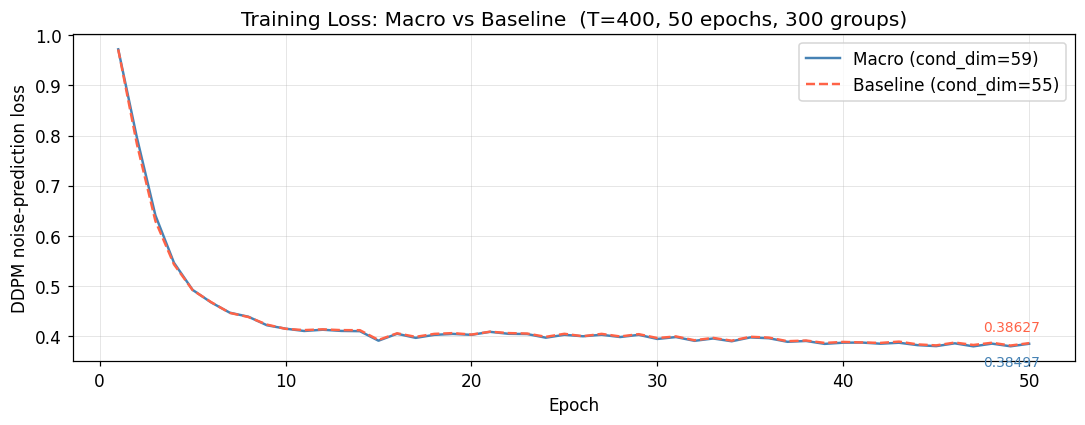


Final loss — macro: 0.384972  baseline: 0.386266  diff: +0.001294 (+0.3%)


In [31]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(hist_macro["epoch"], hist_macro["train_loss"], label=f"Macro (cond_dim={55+K})",
        color="steelblue", lw=1.6)
ax.plot(hist_base["epoch"],  hist_base["train_loss"],  label="Baseline (cond_dim=55)",
        color="tomato", lw=1.6, ls="--")

final_macro = hist_macro["train_loss"].iloc[-1]
final_base  = hist_base["train_loss"].iloc[-1]
ax.annotate(f"{final_macro:.5f}", xy=(TRAIN_EPOCHS, final_macro),
            xytext=(-30, -15), textcoords="offset points", fontsize=9, color="steelblue")
ax.annotate(f"{final_base:.5f}",  xy=(TRAIN_EPOCHS, final_base),
            xytext=(-30, 8),  textcoords="offset points", fontsize=9, color="tomato")

ax.set_xlabel("Epoch")
ax.set_ylabel("DDPM noise-prediction loss")
ax.set_title(f"Training Loss: Macro vs Baseline  (T={T_STEPS}, {TRAIN_EPOCHS} epochs, {SAMPLE_GROUPS} groups)")
ax.legend()
ax.grid(lw=0.4, alpha=0.5)
fig.tight_layout()
plt.savefig(ROOT / "results" / "figures" / "macro_vs_baseline_training_loss.png",
            bbox_inches="tight", dpi=130)
plt.show()

diff = final_base - final_macro
print(f"\nFinal loss — macro: {final_macro:.6f}  baseline: {final_base:.6f}  "
      f"diff: {diff:+.6f} ({'+' if diff >= 0 else ''}{diff/final_base*100:.1f}%)")

## 8. Model Architecture Summary

Confirm the conditioning dimension is correctly wired through the model.

In [25]:
def count_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

print("=" * 55)
print(f"  MACRO model    condition_dim = {55+K}")
print(f"  Input dim      {55} (noised) + {32} (time embed) + {55+K} (cond) = {55+32+(55+K)}")
print(f"  Parameters     {count_params(model_macro):,}")
print()
print(f"  BASELINE model condition_dim = 55")
print(f"  Input dim      55 + 32 + 55 = 142")
print(f"  Parameters     {count_params(model_base):,}")
print("=" * 55)

# Quick forward-pass smoke test
DEVICE_T = torch.device(str(DEVICE))
B = 4
y_dummy  = torch.randn(B, 55, device=DEVICE_T)
t_dummy  = torch.randint(1, T_STEPS + 1, (B,), device=DEVICE_T)

c_macro  = torch.randn(B, 55 + K, device=DEVICE_T)
c_base   = torch.randn(B, 55,     device=DEVICE_T)

model_macro.eval()
model_base.eval()
with torch.no_grad():
    out_macro = model_macro(y_dummy, t_dummy, c_macro)
    out_base  = model_base(y_dummy,  t_dummy, c_base)

print(f"\nForward pass output shapes:")
print(f"  macro  → {tuple(out_macro.shape)}  (expected: ({B}, 55))")
print(f"  base   → {tuple(out_base.shape)}   (expected: ({B}, 55))")
assert out_macro.shape == (B, 55) and out_base.shape == (B, 55), "Shape mismatch!"
print("\n  ✓ Both models produce (batch, 55) noise predictions")

  MACRO model    condition_dim = 59
  Input dim      55 (noised) + 32 (time embed) + 59 (cond) = 146
  Parameters     58,935

  BASELINE model condition_dim = 55
  Input dim      55 + 32 + 55 = 142
  Parameters     58,423

Forward pass output shapes:
  macro  → (4, 55)  (expected: (4, 55))
  base   → (4, 55)   (expected: (4, 55))

  ✓ Both models produce (batch, 55) noise predictions


## 9. Generate Conditional Covariance Scenarios

For a sample validation sleeve we generate M=10 covariance scenarios from both the macro and baseline models,
then compare:
- scenario dispersion (Frobenius distance from the mean)
- diagonal entries (conditional volatilities)
- off-diagonal structure

The macro model's conditioning includes the current macro regime, so its scenario distribution
should respond to high-vol / high-correlation states differently from the baseline.

In [26]:
from src.diffusion import DDPMScheduler
from src.generate import generate_covariance_scenarios, deterministic_scenario_seed, combine_covariances
from src.transforms import covariance_to_log_vech

SCHED_TYPE = "linear"
M = 10

scheduler_macro = DDPMScheduler(SCHED_TYPE, T_STEPS, 1e-4, 0.02, device=DEVICE_T)
scheduler_base  = DDPMScheduler(SCHED_TYPE, T_STEPS, 1e-4, 0.02, device=DEVICE_T)

# Pick a validation sample index — use index 0 (first validated pair)
SAMPLE_IDX = 0

# Raw (unscaled) condition vector for macro model: 55 + K
cond_raw_macro = val_ds_macro["condition_vech"][SAMPLE_IDX]   # (59,)
# Raw (unscaled) condition vector for baseline:   55
cond_raw_base  = val_ds_base["condition_vech"][SAMPLE_IDX]    # (55,)

# Actual future covariance (target) for ground truth comparison
from src.transforms import log_vech_to_covariance
target_vech = val_ds_macro["target_vech"][SAMPLE_IDX]          # (55,)
cov_true    = log_vech_to_covariance(target_vech)

seed = deterministic_scenario_seed(SCHED_TYPE, T_STEPS, pd.Timestamp("2014-01-21"), 0)

print("Generating scenarios from MACRO model …")
scenarios_macro = generate_covariance_scenarios(
    model=model_macro,
    scheduler=scheduler_macro,
    condition_vector_raw=cond_raw_macro,
    conditioning_scaler=cond_scaler_macro,
    target_scaler=tgt_scaler_macro,
    num_scenarios=M,
    seed=seed,
    device=DEVICE_T,
)
print(f"  Generated {len(scenarios_macro)} covariance matrices, each {scenarios_macro[0].shape}")

print("Generating scenarios from BASELINE model …")
scenarios_base = generate_covariance_scenarios(
    model=model_base,
    scheduler=scheduler_base,
    condition_vector_raw=cond_raw_base,
    conditioning_scaler=cond_scaler_base,
    target_scaler=tgt_scaler_base,
    num_scenarios=M,
    seed=seed,
    device=DEVICE_T,
)
print(f"  Generated {len(scenarios_base)} covariance matrices, each {scenarios_base[0].shape}")

Generating scenarios from MACRO model …
  Generated 10 covariance matrices, each (10, 10)
Generating scenarios from BASELINE model …
  Generated 10 covariance matrices, each (10, 10)


In [27]:
# ── Mean covariances and scenario dispersion ──────────────────────────────────
stack_macro = np.stack(scenarios_macro, axis=0)   # (M, 10, 10)
stack_base  = np.stack(scenarios_base, axis=0)

mean_macro  = stack_macro.mean(axis=0)             # (10, 10)
mean_base   = stack_base.mean(axis=0)

# Scenario dispersion: mean Frobenius distance from the mean
def scenario_dispersion(stack, mean_cov):
    diffs = stack - mean_cov[None]
    return float(np.sqrt((diffs**2).sum(axis=(1,2))).mean())

disp_macro = scenario_dispersion(stack_macro, mean_macro)
disp_base  = scenario_dispersion(stack_base,  mean_base)

print(f"Scenario dispersion (mean Frobenius distance from mean cov):")
print(f"  Macro    : {disp_macro:.6f}")
print(f"  Baseline : {disp_base:.6f}")

# Frobenius distance between mean generated cov and ground truth
frob_macro = float(np.linalg.norm(mean_macro - cov_true, 'fro'))
frob_base  = float(np.linalg.norm(mean_base  - cov_true, 'fro'))
print(f"\nFrobenius distance to realized future covariance:")
print(f"  Macro    : {frob_macro:.6f}")
print(f"  Baseline : {frob_base:.6f}")

Scenario dispersion (mean Frobenius distance from mean cov):
  Macro    : 0.001514
  Baseline : 0.002433

Frobenius distance to realized future covariance:
  Macro    : 0.001212
  Baseline : 0.001829


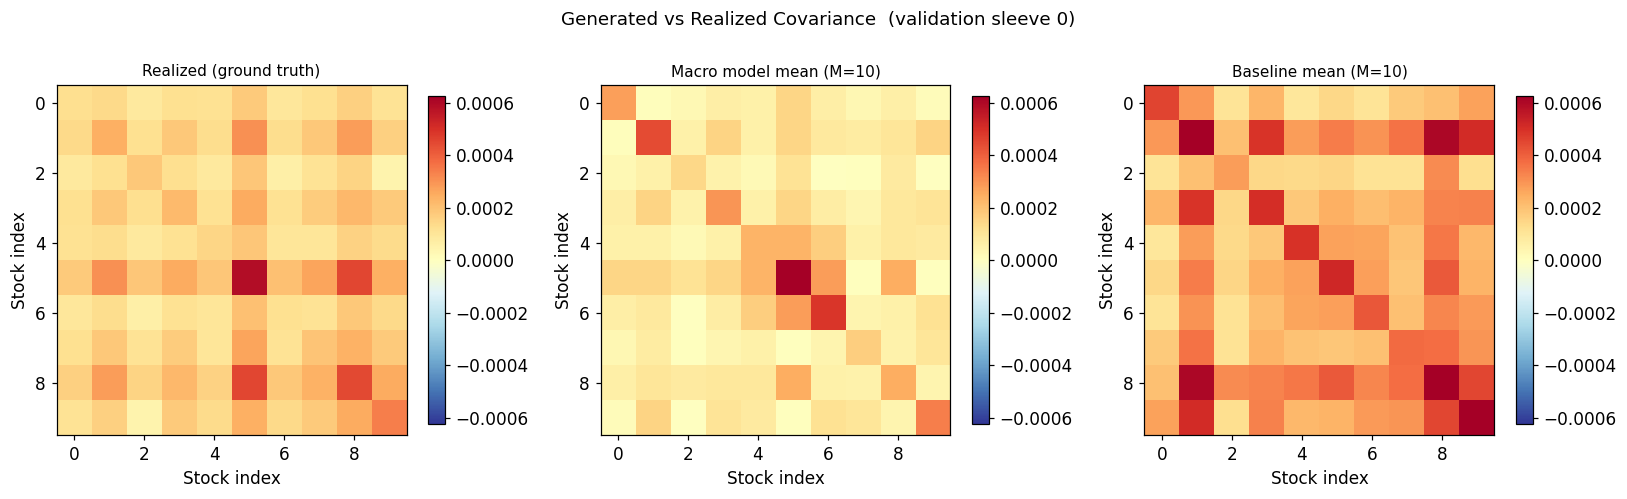

In [28]:
# ── Plot: mean generated covariances vs ground truth ─────────────────────────
vmax = max(np.abs(mean_macro).max(), np.abs(mean_base).max(), np.abs(cov_true).max()) * 0.5

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, mat, title in zip(axes, [cov_true, mean_macro, mean_base],
                          ["Realized (ground truth)",
                           f"Macro model mean (M={M})",
                           f"Baseline mean (M={M})"]):
    im = ax.imshow(mat, cmap="RdYlBu_r", vmin=-vmax, vmax=vmax)
    plt.colorbar(im, ax=ax, shrink=0.8)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Stock index")
    ax.set_ylabel("Stock index")

fig.suptitle(f"Generated vs Realized Covariance  (validation sleeve {SAMPLE_IDX})", fontsize=12)
fig.tight_layout()
plt.savefig(ROOT / "results" / "figures" / "macro_vs_baseline_scenarios.png",
            bbox_inches="tight", dpi=130)
plt.show()

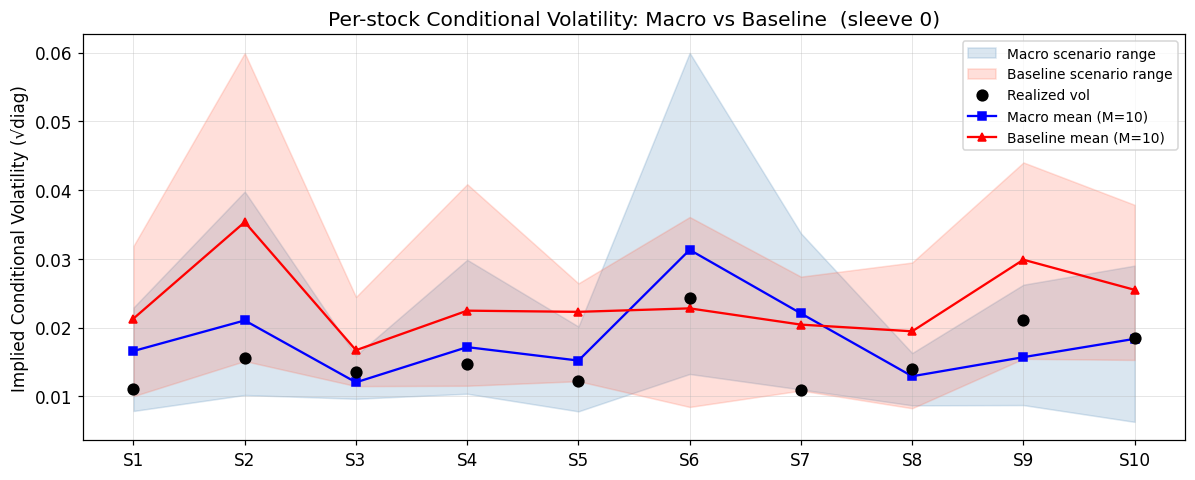

In [29]:
# ── Plot: implied conditional volatilities (sqrt of diagonal) ────────────────
stocks = [f"S{i+1}" for i in range(10)]

vol_true  = np.sqrt(np.diag(cov_true))
vol_macro = np.sqrt(np.diag(mean_macro))
vol_base  = np.sqrt(np.diag(mean_base))

# Also show the scenario band
vol_macro_all = np.sqrt(np.stack([np.diag(s) for s in scenarios_macro]))  # (M, 10)
vol_base_all  = np.sqrt(np.stack([np.diag(s) for s in scenarios_base]))

x = np.arange(10)
fig, ax = plt.subplots(figsize=(11, 4.5))

ax.fill_between(x, vol_macro_all.min(axis=0), vol_macro_all.max(axis=0),
                alpha=0.2, color="steelblue", label="Macro scenario range")
ax.fill_between(x, vol_base_all.min(axis=0),  vol_base_all.max(axis=0),
                alpha=0.2, color="tomato",    label="Baseline scenario range")
ax.plot(x, vol_true,  "ko",  ms=7,  label="Realized vol", zorder=5)
ax.plot(x, vol_macro, "b-s", ms=5,  label=f"Macro mean (M={M})")
ax.plot(x, vol_base,  "r-^", ms=5,  label=f"Baseline mean (M={M})")

ax.set_xticks(x)
ax.set_xticklabels(stocks)
ax.set_ylabel("Implied Conditional Volatility (√diag)")
ax.set_title(f"Per-stock Conditional Volatility: Macro vs Baseline  (sleeve {SAMPLE_IDX})")
ax.legend(fontsize=9)
ax.grid(lw=0.4, alpha=0.5)
fig.tight_layout()
plt.savefig(ROOT / "results" / "figures" / "macro_vs_baseline_vol_comparison.png",
            bbox_inches="tight", dpi=130)
plt.show()

## 10. Macro Feature Values at the Sample Observation

Show what macro regime the model is conditioning on for this validation sleeve.

In [30]:
# The last K elements of the raw conditioning vector are the macro features
macro_at_sample = cond_raw_macro[-K:]
# The rebalance date for this sleeve
sample_meta = val_ds_macro["metadata"].iloc[SAMPLE_IDX]

print(f"Validation sleeve {SAMPLE_IDX} — rebalance date: {sample_meta.get('rebalance_date', 'N/A')}")
print()
print(f"{'Feature':<25}  {'Raw value':>12}  {'Interpretation':<40}")
print("-" * 80)
interpretations = {
    "log_mkt_var_21d":        "short-horizon vol regime",
    "log_mkt_var_126d":       "long-run vol component",
    "mkt_ret_21d":            "leverage-effect signal",
    "avg_pairwise_corr_126d": "systematic-risk concentration",
    "log_vix":                "implied-vol expectation",
    "term_spread":            "recession indicator",
    "credit_spread":          "financial-distress signal",
}
for feat, val in zip(macro_df.columns, macro_at_sample):
    print(f"{feat:<25}  {val:>12.5f}  {interpretations.get(feat, ''):<40}")

Validation sleeve 0 — rebalance date: 2013-12-31 00:00:00

Feature                       Raw value  Interpretation                          
--------------------------------------------------------------------------------
log_mkt_var_21d               -10.12409  short-horizon vol regime                
log_mkt_var_126d               -9.96864  long-run vol component                  
mkt_ret_21d                     0.03308  leverage-effect signal                  
avg_pairwise_corr_126d          0.05176  systematic-risk concentration           


## 11. Batch Evaluation: Frobenius Loss Across Validation Set

Compute the mean Frobenius distance between the model's mean generated covariance
and the realized future covariance proxy over all sampled validation sleeves.

> **Note:** This is a *diagnostic*, not the hyperparameter-selection metric.  
> The spec requires selecting hyperparameters using realized GMV portfolio volatility only.

In [ ]:
from src.transforms import log_vech_to_covariance

N_EVAL = min(50, len(val_ds_macro["condition_vech"]))   # limit for speed
M_EVAL = 5

frob_losses = {"macro": [], "baseline": []}

model_macro.eval()
model_base.eval()

print(f"Evaluating Frobenius loss on {N_EVAL} validation observations (M={M_EVAL}) …")

for idx in range(N_EVAL):
    cov_realized = log_vech_to_covariance(val_ds_macro["target_vech"][idx])

    for model, cond_raw_all, scaler_c, scaler_t, sched, key in [
        (model_macro, val_ds_macro["condition_vech"], cond_scaler_macro, tgt_scaler_macro, scheduler_macro, "macro"),
        (model_base,  val_ds_base["condition_vech"],  cond_scaler_base,  tgt_scaler_base,  scheduler_base,  "baseline"),
    ]:
        cond_raw = cond_raw_all[idx]
        scenarios = generate_covariance_scenarios(
            model=model,
            scheduler=sched,
            condition_vector_raw=cond_raw,
            conditioning_scaler=scaler_c,
            target_scaler=scaler_t,
            num_scenarios=M_EVAL,
            seed=idx,          # deterministic per observation
            device=DEVICE_T,
        )
        mean_cov = np.mean(np.stack(scenarios, axis=0), axis=0)
        frob = float(np.linalg.norm(mean_cov - cov_realized, 'fro'))
        frob_losses[key].append(frob)

    if (idx + 1) % 10 == 0:
        print(f"  {idx+1}/{N_EVAL} …")

print("\nFrobenius loss (mean ± std) over validation sample:")
for key in ["macro", "baseline"]:
    arr = np.array(frob_losses[key])
    print(f"  {key:>8}: {arr.mean():.6f} ± {arr.std():.6f}")

Evaluating Frobenius loss on 48 validation observations (M=5) …
  10/48 …
  20/48 …
  30/48 …
  40/48 …


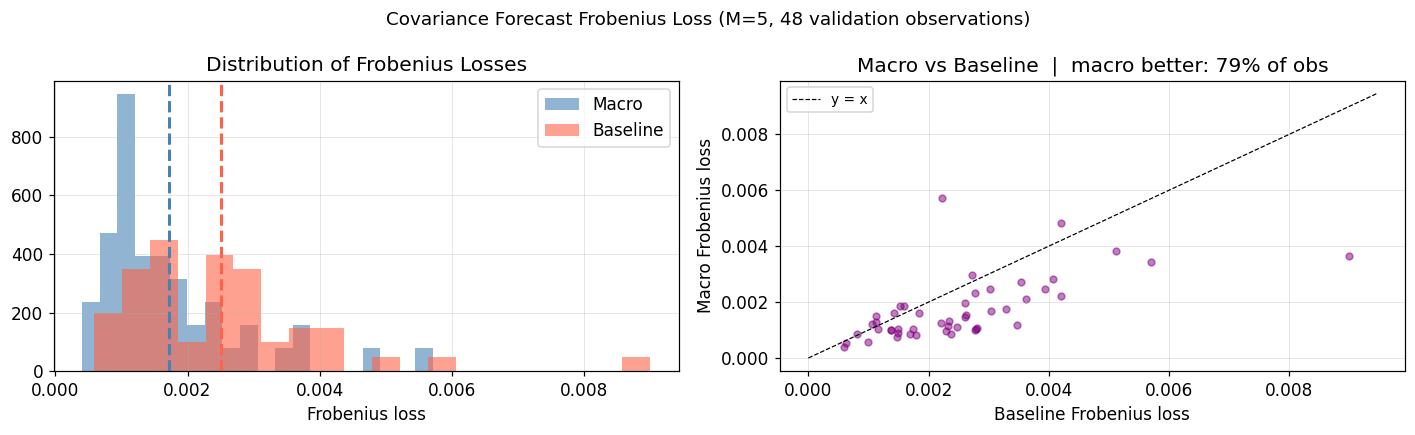

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Distribution of Frobenius losses
ax = axes[0]
ax.hist(frob_losses["macro"],    bins=20, alpha=0.6, color="steelblue", label="Macro",    density=True)
ax.hist(frob_losses["baseline"], bins=20, alpha=0.6, color="tomato",    label="Baseline", density=True)
ax.axvline(np.mean(frob_losses["macro"]),    color="steelblue", lw=2, ls="--")
ax.axvline(np.mean(frob_losses["baseline"]), color="tomato",    lw=2, ls="--")
ax.set_xlabel("Frobenius loss")
ax.set_title("Distribution of Frobenius Losses")
ax.legend()
ax.grid(lw=0.4, alpha=0.5)

# Scatter: macro vs baseline loss per observation
ax = axes[1]
ax.scatter(frob_losses["baseline"], frob_losses["macro"],
           s=20, alpha=0.5, color="purple")
lim = max(max(frob_losses["macro"]), max(frob_losses["baseline"])) * 1.05
ax.plot([0, lim], [0, lim], "k--", lw=0.8, label="y = x")
ax.set_xlabel("Baseline Frobenius loss")
ax.set_ylabel("Macro Frobenius loss")
ax.set_title("Macro vs Baseline: per-observation Frobenius loss")
frac_better = np.mean(np.array(frob_losses["macro"]) < np.array(frob_losses["baseline"]))
ax.set_title(f"Macro vs Baseline  |  macro better: {frac_better*100:.0f}% of obs")
ax.legend(fontsize=9)
ax.grid(lw=0.4, alpha=0.5)

fig.suptitle(f"Covariance Forecast Frobenius Loss (M={M_EVAL}, {N_EVAL} validation observations)", fontsize=12)
fig.tight_layout()
plt.savefig(ROOT / "results" / "figures" / "macro_vs_baseline_frobenius_loss.png",
            bbox_inches="tight", dpi=130)
plt.show()

## 12. Macro-Regime Conditioning: High-Vol vs Low-Vol Comparison

Show that the macro-conditioned model generates different scenario distributions 
in high-volatility vs low-volatility regimes, while the baseline model's distribution
shifts only due to the covariance vech.

In [31]:
# Sort validation observations by the short-horizon vol feature
log_var_21d_vals = val_ds_macro["condition_vech"][:, 55]   # first macro feature
sorted_idxs = np.argsort(log_var_21d_vals)

N_COMPARE = min(10, len(sorted_idxs) // 4)
low_vol_idxs  = sorted_idxs[:N_COMPARE]      # lowest log_mkt_var_21d
high_vol_idxs = sorted_idxs[-N_COMPARE:]     # highest log_mkt_var_21d

print(f"Low-vol  macro feature (log_mkt_var_21d) range: "
      f"[{log_var_21d_vals[low_vol_idxs].min():.3f}, {log_var_21d_vals[low_vol_idxs].max():.3f}]")
print(f"High-vol macro feature (log_mkt_var_21d) range: "
      f"[{log_var_21d_vals[high_vol_idxs].min():.3f}, {log_var_21d_vals[high_vol_idxs].max():.3f}]")


def collect_mean_diag_vols(model, scaler_c, scaler_t, sched, cond_raw_all, idxs, M=5):
    """Generate M scenarios per obs in idxs and return mean diagonal vols."""
    all_diag_vols = []
    for idx in idxs:
        cond_raw = cond_raw_all[idx]
        scenarios = generate_covariance_scenarios(
            model=model, scheduler=sched,
            condition_vector_raw=cond_raw,
            conditioning_scaler=scaler_c, target_scaler=scaler_t,
            num_scenarios=M, seed=int(idx), device=DEVICE_T,
        )
        mean_cov = np.mean(np.stack(scenarios, axis=0), axis=0)
        all_diag_vols.append(np.sqrt(np.diag(mean_cov)))
    return np.array(all_diag_vols)   # (N_COMPARE, 10)


print("\nGenerating regime-split scenarios …")
M_REGIME = 5
macro_low_vols   = collect_mean_diag_vols(model_macro, cond_scaler_macro, tgt_scaler_macro,
                                          scheduler_macro, val_ds_macro["condition_vech"],
                                          low_vol_idxs,  M=M_REGIME)
macro_high_vols  = collect_mean_diag_vols(model_macro, cond_scaler_macro, tgt_scaler_macro,
                                          scheduler_macro, val_ds_macro["condition_vech"],
                                          high_vol_idxs, M=M_REGIME)
base_low_vols    = collect_mean_diag_vols(model_base, cond_scaler_base, tgt_scaler_base,
                                          scheduler_base, val_ds_base["condition_vech"],
                                          low_vol_idxs,  M=M_REGIME)
base_high_vols   = collect_mean_diag_vols(model_base, cond_scaler_base, tgt_scaler_base,
                                          scheduler_base, val_ds_base["condition_vech"],
                                          high_vol_idxs, M=M_REGIME)

Low-vol  macro feature (log_mkt_var_21d) range: [-10.124, -10.124]
High-vol macro feature (log_mkt_var_21d) range: [-9.380, -9.380]

Generating regime-split scenarios …


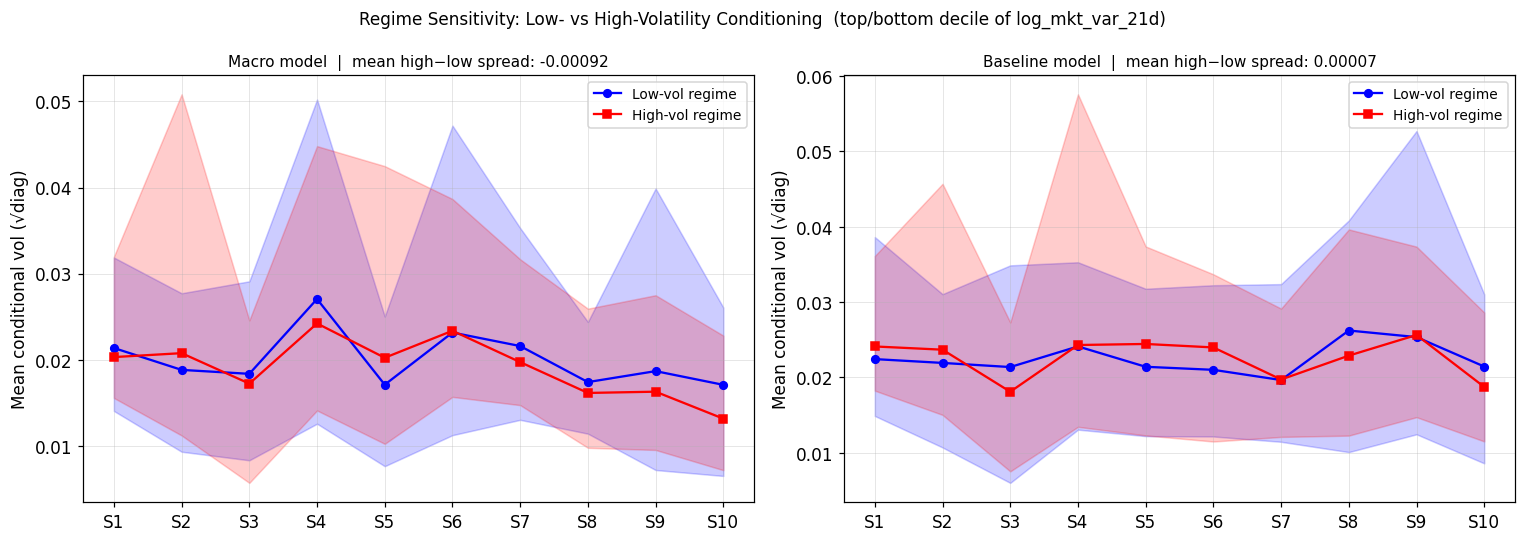

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
x = np.arange(10)
stocks = [f"S{i+1}" for i in range(10)]

for ax, model_label, low_vols, high_vols in [
    (axes[0], "Macro model",    macro_low_vols,  macro_high_vols),
    (axes[1], "Baseline model", base_low_vols,   base_high_vols),
]:
    ax.plot(x, low_vols.mean(axis=0),  "b-o", ms=5, label="Low-vol regime")
    ax.fill_between(x, low_vols.min(axis=0),  low_vols.max(axis=0),  alpha=0.2, color="blue")
    ax.plot(x, high_vols.mean(axis=0), "r-s", ms=5, label="High-vol regime")
    ax.fill_between(x, high_vols.min(axis=0), high_vols.max(axis=0), alpha=0.2, color="red")
    spread = (high_vols.mean(axis=0) - low_vols.mean(axis=0)).mean()
    ax.set_title(f"{model_label}  |  mean high−low spread: {spread:.5f}", fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels(stocks)
    ax.set_ylabel("Mean conditional vol (√diag)")
    ax.legend(fontsize=9)
    ax.grid(lw=0.4, alpha=0.5)

fig.suptitle("Regime Sensitivity: Low- vs High-Volatility Conditioning  (top/bottom decile of log_mkt_var_21d)",
             fontsize=11)
fig.tight_layout()
plt.savefig(ROOT / "results" / "figures" / "macro_regime_sensitivity.png",
            bbox_inches="tight", dpi=130)
plt.show()

## 13. Summary and Next Steps

This notebook demonstrated the macro-augmented conditional diffusion pipeline end-to-end.

In [33]:
print("=" * 65)
print("  SUMMARY")
print("=" * 65)
print()
print(f"  Macro features:       {list(macro_df.columns)}")
print(f"  condition_dim:        55 + {K} = {55+K}")
print(f"  Denoiser input dim:   55 + 32 + {55+K} = {55+32+55+K}")
print()
print(f"  Training set:         {len(train_ds_macro['condition_vech']):,} pairs "
      f"({SAMPLE_GROUPS} groups, stride=1)")
print(f"  Validation sample:    {N_EVAL} sleeves (out of {len(val_ds_macro['condition_vech'])} total)")
print()
print(f"  Training epochs:      {TRAIN_EPOCHS}  (full pipeline: 200)")
print(f"  T (diffusion steps):  {T_STEPS}  (full grid: 400/800/1200/2000)")
print()
print(f"  Final training loss:")
print(f"    Macro    : {hist_macro['train_loss'].iloc[-1]:.6f}")
print(f"    Baseline : {hist_base['train_loss'].iloc[-1]:.6f}")
print()
print(f"  Frobenius loss (validation, M={M_EVAL}):")
print(f"    Macro    : {np.mean(frob_losses['macro']):.6f} ± {np.std(frob_losses['macro']):.6f}")
print(f"    Baseline : {np.mean(frob_losses['baseline']):.6f} ± {np.std(frob_losses['baseline']):.6f}")
print()
print("  Saved figures to results/figures/:")
for fname in [
    "macro_features_time_series.png",
    "macro_feature_correlations.png",
    "macro_vs_baseline_training_loss.png",
    "macro_vs_baseline_scenarios.png",
    "macro_vs_baseline_vol_comparison.png",
    "macro_vs_baseline_frobenius_loss.png",
    "macro_regime_sensitivity.png",
]:
    p = ROOT / "results" / "figures" / fname
    print(f"    {'✓' if p.exists() else '✗'} {fname}")
print()
print("  Next steps:")
print("  1. Run scripts/03_build_covariance_datasets.py with macro enabled")
print("     to rebuild the full (n, 59)-dim training/val/test NPZ files.")
print("  2. Run scripts/04_train_diffusion_models.py — condition_dim auto-detected.")
print("  3. Run scripts/05_validate_hyperparameters.py for final model selection.")
print("  (Optional) Run scripts/00_download_macro_data.py first to add")
print("     3 FRED features (VIX, term spread, IG OAS) → condition_dim=62.")
print("=" * 65)

  SUMMARY

  Macro features:       ['log_mkt_var_21d', 'log_mkt_var_126d', 'mkt_ret_21d', 'avg_pairwise_corr_126d']
  condition_dim:        55 + 4 = 59
  Denoiser input dim:   55 + 32 + 59 = 146

  Training set:         5,522 pairs (300 groups, stride=1)
  Validation sample:    48 sleeves (out of 48 total)

  Training epochs:      50  (full pipeline: 200)
  T (diffusion steps):  400  (full grid: 400/800/1200/2000)

  Final training loss:
    Macro    : 0.384972
    Baseline : 0.386266

  Frobenius loss (validation, M=5):
    Macro    : 0.001723 ± 0.001099
    Baseline : 0.002509 ± 0.001481

  Saved figures to results/figures/:
    ✓ macro_features_time_series.png
    ✓ macro_feature_correlations.png
    ✓ macro_vs_baseline_training_loss.png
    ✓ macro_vs_baseline_scenarios.png
    ✓ macro_vs_baseline_vol_comparison.png
    ✓ macro_vs_baseline_frobenius_loss.png
    ✓ macro_regime_sensitivity.png

  Next steps:
  1. Run scripts/03_build_covariance_datasets.py with macro enabled
     to

## 14. Full Validation: Alpha × M Grid (Macro vs Baseline)

Mirrors `scripts/05_validate_hyperparameters.py` exactly on **both models**:
- **Macro model** — condition_dim = 59 (55 log-vech + 4 CRSP macro features)
- **Baseline model** — condition_dim = 55 (log-vech only)

Search grid for each model:
- α ∈ {0.00, 0.25, 0.50, 0.75} × M ∈ {1, 5, 10, 20, 50} = 20 configurations
- Plus α = 1.0 (sample covariance GMV boundary, evaluated once)

**Selection metric (spec §24.3):** annualized realized GMV portfolio volatility over 2014–2020.  
Results saved to `results/validation/alt_validation_grid_results.csv`.

> All intermediate results are disk-cached so re-runs are fast.

In [34]:
import pickle

from src.covariance import build_covariance_pair
from src.groups import get_sleeve_permnos
from src.backtest import run_one_rebalance
from src.metrics import annualized_volatility
from src.gmv import solve_long_only_gmv

try:
    from tqdm.auto import tqdm as _tqdm
    _has_tqdm = True
except ImportError:
    _has_tqdm = False

# Hyperparameter search grid
ALPHA_GRID = [0.00, 0.25, 0.50, 0.75]
M_GRID     = [1, 5, 10, 20, 50]
M_MAX      = 50
LKB        = 126
HOR        = 21

# Output directories (separate from main pipeline cache)
ALT_VAL_DIR   = ROOT / "results" / "validation"
ALT_CACHE_DIR = ALT_VAL_DIR / "cache_alt"
ALT_VAL_DIR.mkdir(parents=True, exist_ok=True)
ALT_CACHE_DIR.mkdir(parents=True, exist_ok=True)

print(f"Alpha grid : {ALPHA_GRID}")
print(f"M grid     : {M_GRID}  (M_max = {M_MAX})")
print(f"Cache dir  : {ALT_CACHE_DIR}")

Alpha grid : [0.0, 0.25, 0.5, 0.75]
M grid     : [1, 5, 10, 20, 50]  (M_max = 50)
Cache dir  : /Users/brianrhie/Documents/Quant/Find-A/Final/results/validation/cache_alt


In [35]:

# Guard: define path constants if cell 43 (imports cell) wasn't fully executed
if "ALT_CACHE_DIR" not in dir():
    from pathlib import Path as _P
    ALT_VAL_DIR   = _P(".").resolve() / "results" / "validation"
    ALT_CACHE_DIR = ALT_VAL_DIR / "cache_alt"
    ALT_VAL_DIR.mkdir(parents=True, exist_ok=True)
    ALT_CACHE_DIR.mkdir(parents=True, exist_ok=True)

if "LKB" not in dir():
    LKB = 126
if "HOR" not in dir():
    HOR = 21

# Full validation rebalance dates — all dates in the validation window, not just the 50-sleeve subsample
val_dates_all = sorted(val_sleeves_df["rebalance_date"].unique())
print(f"Validation rebalance dates: {len(val_dates_all)}")
print(f"  {val_dates_all[0].date()}  →  {val_dates_all[-1].date()}")
n_sleeves_total = val_sleeves_df["sleeve_id"].nunique()
print(f"Total validation sleeves (all dates): {n_sleeves_total}")
print(f"Cache dir: {ALT_CACHE_DIR}")

# ── Precompute sample covariances (with disk cache) ───────────────────────────
SCOV_CACHE = ALT_CACHE_DIR / "sample_covs_alt.pkl"

if SCOV_CACHE.exists():
    print(f"\n✓ Loading cached sample covariances …")
    import pickle as _pickle
    with open(SCOV_CACHE, "rb") as fh:
        _sc = _pickle.load(fh)
    sleeve_permnos_by_date    = _sc["sleeve_permnos_by_date"]
    sleeve_sample_cov_by_date = _sc["sleeve_sample_cov_by_date"]
    n_computed = sum(len(v) for v in sleeve_sample_cov_by_date.values())
    print(f"  {len(sleeve_permnos_by_date)} dates, {n_computed} sleeve-date sample covariances loaded")
else:
    avg_per_date = n_sleeves_total // len(val_dates_all)
    print(f"\nComputing sample covariances ({len(val_dates_all)} dates × ~{avg_per_date} sleeves each) …")
    sleeve_permnos_by_date    = {}
    sleeve_sample_cov_by_date = {}

    date_iter = _tqdm(val_dates_all, desc="Dates", unit="date") if _has_tqdm else val_dates_all
    for date in date_iter:
        date_sleeves = val_sleeves_df[val_sleeves_df["rebalance_date"] == date]
        for sid in date_sleeves["sleeve_id"].unique():
            permnos = get_sleeve_permnos(date_sleeves, sid)
            result  = build_covariance_pair(
                crsp_df, trading_dates, permnos, date,
                lookback_days=LKB, horizon_days=HOR,
            )
            if result is None:
                continue
            S_hist, _, _, _ = result
            sleeve_permnos_by_date.setdefault(date, {})[sid]    = permnos
            sleeve_sample_cov_by_date.setdefault(date, {})[sid] = S_hist

    import pickle as _pickle
    with open(SCOV_CACHE, "wb") as fh:
        _pickle.dump({
            "sleeve_permnos_by_date":    sleeve_permnos_by_date,
            "sleeve_sample_cov_by_date": sleeve_sample_cov_by_date,
        }, fh, protocol=_pickle.HIGHEST_PROTOCOL)
    n_computed = sum(len(v) for v in sleeve_sample_cov_by_date.values())
    print(f"✓ Cached {len(sleeve_permnos_by_date)} dates, {n_computed} sleeve-dates → {SCOV_CACHE.name}")


Validation rebalance dates: 84
  2013-12-31  →  2020-12-31
Total validation sleeves (all dates): 2522
Cache dir: /Users/brianrhie/Documents/Quant/Find-A/Final/results/validation/cache_alt

Computing sample covariances (84 dates × ~30 sleeves each) …


Dates:   0%|          | 0/84 [00:00<?, ?date/s]

✓ Cached 84 dates, 2453 sleeve-dates → sample_covs_alt.pkl


In [36]:
from src.transforms import covariance_to_log_vech
from src.macro_features import get_macro_vector


def _generate_and_cache(model, scheduler, scaler_c, scaler_t,
                         macro_df_arg, label, cache_path):
    """Generate M_MAX=50 scenarios per sleeve-date, with disk caching."""
    if cache_path.exists():
        print(f"✓ Loading cached scenarios [{label}]: {cache_path.name}")
        with open(cache_path, "rb") as fh:
            return pickle.load(fh)

    print(f"\nGenerating {M_MAX} scenarios per sleeve-date [{label}] …")
    model.eval()
    cache = {}

    all_pairs = [
        (d, sid)
        for d in val_dates_all
        for sid in sleeve_sample_cov_by_date.get(d, {})
    ]
    iter_ = _tqdm(all_pairs, desc=f"  {label}", unit="sleeve") if _has_tqdm else all_pairs

    for date, sid in iter_:
        S_hist = sleeve_sample_cov_by_date[date][sid]
        try:
            cov_vech = covariance_to_log_vech(S_hist, 1e-8)
        except Exception:
            continue

        if macro_df_arg is not None:
            macro_vec = get_macro_vector(macro_df_arg, date)
            cond_raw  = np.concatenate([cov_vech, macro_vec])
        else:
            cond_raw = cov_vech

        gen_seed  = deterministic_scenario_seed(SCHED_TYPE, T_STEPS, date, sid)
        scenarios = generate_covariance_scenarios(
            model=model, scheduler=scheduler,
            condition_vector_raw=cond_raw,
            conditioning_scaler=scaler_c, target_scaler=scaler_t,
            num_scenarios=M_MAX, seed=gen_seed, device=DEVICE_T,
        )
        cache[(date, sid)] = scenarios

    with open(cache_path, "wb") as fh:
        pickle.dump(cache, fh, protocol=pickle.HIGHEST_PROTOCOL)
    print(f"✓ Cached {len(cache)} sleeve-dates → {cache_path.name}")
    return cache


scen_cache_macro = _generate_and_cache(
    model_macro, scheduler_macro, cond_scaler_macro, tgt_scaler_macro,
    macro_df, "macro",
    ALT_CACHE_DIR / f"scenarios_macro_T{T_STEPS}_alt.pkl",
)
scen_cache_base = _generate_and_cache(
    model_base, scheduler_base, cond_scaler_base, tgt_scaler_base,
    None, "baseline",
    ALT_CACHE_DIR / f"scenarios_base_T{T_STEPS}_alt.pkl",
)
print(f"\nScenario caches ready:  macro={len(scen_cache_macro)}, baseline={len(scen_cache_base)} sleeve-dates")


Generating 50 scenarios per sleeve-date [macro] …


  macro:   0%|          | 0/2453 [00:00<?, ?sleeve/s]

✓ Cached 2453 sleeve-dates → scenarios_macro_T400_alt.pkl

Generating 50 scenarios per sleeve-date [baseline] …


  baseline:   0%|          | 0/2453 [00:00<?, ?sleeve/s]

✓ Cached 2453 sleeve-dates → scenarios_base_T400_alt.pkl

Scenario caches ready:  macro=2453, baseline=2453 sleeve-dates


In [37]:
def _run_val_backtest(wts_by_date):
    """Concatenate gross daily returns over all validation holding periods."""
    all_rets = []
    for date in val_dates_all:
        wts  = wts_by_date.get(date, {})
        perm = sleeve_permnos_by_date.get(date, {})
        if not wts or not perm:
            continue
        daily_rets, _, _, _ = run_one_rebalance(
            sleeve_weights=wts,
            sleeve_permnos=perm,
            crsp_df=crsp_df,
            trading_dates=trading_dates,
            rebalance_date=date,
            horizon_days=HOR,
        )
        all_rets.extend(daily_rets)
    return all_rets


val_results = []

# ── alpha=1: sample covariance GMV (boundary, evaluated once) ────────────────
print("alpha=1 (sample covariance GMV) …")
sample_wts = {}
for date in val_dates_all:
    sample_wts[date] = {}
    for sid, S_hist in sleeve_sample_cov_by_date.get(date, {}).items():
        try:
            sample_wts[date][sid] = solve_long_only_gmv(S_hist)
        except Exception:
            pass

sample_rets = _run_val_backtest(sample_wts)
sample_vol  = annualized_volatility(np.array(sample_rets)) if sample_rets else np.nan
val_results.append({
    "model": "sample_cov", "alpha": 1.0, "M": None,
    "val_vol": sample_vol, "is_boundary": True,
})
print(f"  alpha=1.00  M=—  →  val_vol={sample_vol:.6f}")

# ── Diffusion-blend sweep ─────────────────────────────────────────────────────
model_runs = [
    ("macro",    scen_cache_macro),
    ("baseline", scen_cache_base),
]

for model_label, scen_cache in model_runs:
    n_configs = len(ALPHA_GRID) * len(M_GRID)
    print(f"\n{model_label} model — {n_configs} configurations …")
    best_vol = np.inf

    for M in M_GRID:
        for alpha in ALPHA_GRID:
            wts_by_date = {}
            for date in val_dates_all:
                wts_by_date[date] = {}
                for sid, S_hist in sleeve_sample_cov_by_date.get(date, {}).items():
                    key = (date, sid)
                    if key not in scen_cache:
                        continue
                    combined = combine_covariances(S_hist, scen_cache[key][:M], alpha)
                    try:
                        wts_by_date[date][sid] = solve_long_only_gmv(combined)
                    except Exception:
                        pass

            rets = _run_val_backtest(wts_by_date)
            vol  = annualized_volatility(np.array(rets)) if rets else np.nan
            best_vol = min(best_vol, vol)
            marker   = " ◀ best" if vol == best_vol else ""

            val_results.append({
                "model": model_label, "alpha": alpha, "M": M,
                "val_vol": vol, "is_boundary": False,
            })
            print(f"  {model_label:<10}  alpha={alpha:.2f}  M={M:>2}  →  {vol:.6f}  ({vol*100:.4f}%){marker}")

print("\nSweep complete.")

alpha=1 (sample covariance GMV) …
  alpha=1.00  M=—  →  val_vol=0.159980

macro model — 20 configurations …
  macro       alpha=0.00  M= 1  →  0.177921  (17.7921%) ◀ best
  macro       alpha=0.25  M= 1  →  0.169649  (16.9649%) ◀ best
  macro       alpha=0.50  M= 1  →  0.166420  (16.6420%) ◀ best
  macro       alpha=0.75  M= 1  →  0.163517  (16.3517%) ◀ best
  macro       alpha=0.00  M= 5  →  0.173753  (17.3753%)
  macro       alpha=0.25  M= 5  →  0.168147  (16.8147%)
  macro       alpha=0.50  M= 5  →  0.165180  (16.5180%)
  macro       alpha=0.75  M= 5  →  0.162693  (16.2693%) ◀ best
  macro       alpha=0.00  M=10  →  0.173152  (17.3152%)
  macro       alpha=0.25  M=10  →  0.168062  (16.8062%)
  macro       alpha=0.50  M=10  →  0.165319  (16.5319%)
  macro       alpha=0.75  M=10  →  0.162969  (16.2969%)
  macro       alpha=0.00  M=20  →  0.173379  (17.3379%)
  macro       alpha=0.25  M=20  →  0.168180  (16.8180%)
  macro       alpha=0.50  M=20  →  0.165422  (16.5422%)
  macro       alp

In [38]:
results_df = pd.DataFrame(val_results).sort_values("val_vol").reset_index(drop=True)
results_df["rank"] = results_df.index + 1

# ── Top-15 table ──────────────────────────────────────────────────────────────
print("=" * 70)
print("FULL VALIDATION — Top 15 configurations  (2014–2020)")
print("=" * 70)
print(f"  {'Rank':>3}  {'Model':<12}  {'alpha':>5}  {'M':>4}  {'Val Vol':>9}  {'Val Vol%':>9}")
print("-" * 70)
for _, row in results_df.head(15).iterrows():
    M_str = f"{int(row['M'])}" if pd.notna(row["M"]) else "—"
    print(f"  {int(row['rank']):>3}  {row['model']:<12}  {row['alpha']:>5.2f}  "
          f"{M_str:>4}  {row['val_vol']:>9.6f}  {row['val_vol']*100:>8.4f}%")
print()

# ── Best per model ─────────────────────────────────────────────────────────────
print("Best configuration per model:")
for label in ["macro", "baseline", "sample_cov"]:
    sub = results_df[results_df["model"] == label]
    if sub.empty:
        continue
    best = sub.iloc[0]
    M_str    = f"M={int(best['M'])}" if pd.notna(best["M"]) else "M=—"
    vs_sample = (1 - best["val_vol"] / sample_vol) * 100
    print(f"  {label:<14}  alpha={best['alpha']:.2f}  {M_str}  "
          f"val_vol={best['val_vol']:.6f}  ({vs_sample:+.2f}% vs sample cov GMV)")

# ── Save CSV ──────────────────────────────────────────────────────────────────
out_path = ALT_VAL_DIR / "alt_validation_grid_results.csv"
results_df.to_csv(out_path, index=False)
print(f"\nSaved → {out_path}")

FULL VALIDATION — Top 15 configurations  (2014–2020)
  Rank  Model         alpha     M    Val Vol   Val Vol%
----------------------------------------------------------------------
    1  sample_cov     1.00     —   0.159980   15.9980%
    2  baseline       0.75    50   0.162409   16.2409%
    3  baseline       0.75    20   0.162449   16.2449%
    4  macro          0.75     5   0.162693   16.2693%
    5  baseline       0.75    10   0.162714   16.2714%
    6  baseline       0.75     5   0.162962   16.2962%
    7  macro          0.75    20   0.162965   16.2965%
    8  macro          0.75    10   0.162969   16.2969%
    9  macro          0.75    50   0.162995   16.2995%
   10  macro          0.75     1   0.163517   16.3517%
   11  baseline       0.75     1   0.164173   16.4173%
   12  baseline       0.50    50   0.164640   16.4640%
   13  baseline       0.50    20   0.164912   16.4912%
   14  macro          0.50     5   0.165180   16.5180%
   15  macro          0.50    10   0.165319   16.5

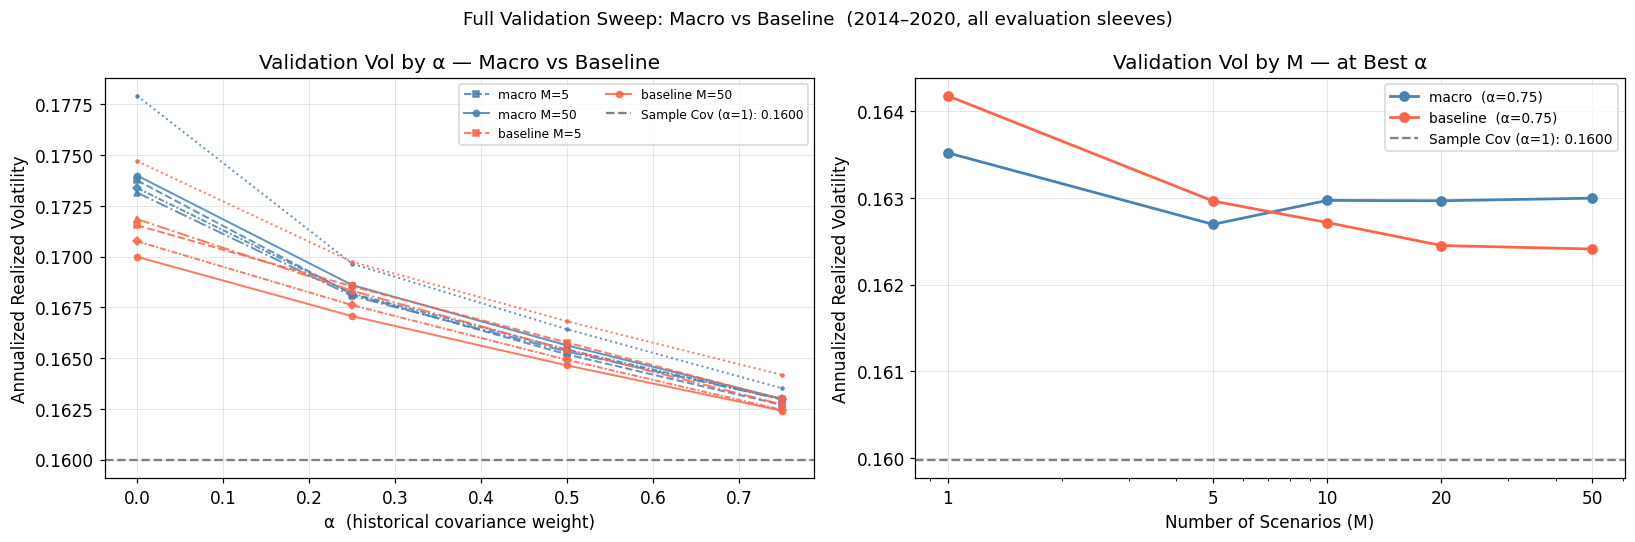

Saved → results/figures/alt_validation_sweep.png


In [39]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

colors = {"macro": "steelblue", "baseline": "tomato"}
ls_map = {1: ":", 5: "--", 10: "-.", 20: (0, (3, 1, 1, 1)), 50: "-"}
mk_map = {1: ".", 5: "s", 10: "^", 20: "D", 50: "o"}

# ── Left: vol by alpha ────────────────────────────────────────────────────────
ax = axes[0]
for label in ["macro", "baseline"]:
    sub = results_df[(results_df["model"] == label) & ~results_df["is_boundary"]]
    for M in M_GRID:
        m_sub = sub[sub["M"] == M].sort_values("alpha")
        if m_sub.empty:
            continue
        ax.plot(
            m_sub["alpha"], m_sub["val_vol"],
            color=colors[label], ls=ls_map[M], marker=mk_map[M],
            ms=4, lw=1.3, alpha=0.85,
            label=f"{label} M={M}" if M in (5, 50) else None,
        )

ax.axhline(sample_vol, color="gray", ls="--", lw=1.5,
           label=f"Sample Cov (α=1): {sample_vol:.4f}")
ax.set_xlabel("α  (historical covariance weight)")
ax.set_ylabel("Annualized Realized Volatility")
ax.set_title("Validation Vol by α — Macro vs Baseline")
ax.legend(fontsize=8, ncol=2, loc="best")
ax.grid(lw=0.4, alpha=0.5)

# ── Right: vol by M at best alpha per model ───────────────────────────────────
ax = axes[1]
for label, color in colors.items():
    sub = results_df[results_df["model"] == label]
    best_alpha = sub.groupby("alpha")["val_vol"].mean().idxmin()
    alpha_sub  = sub[sub["alpha"] == best_alpha].sort_values("M").dropna(subset=["M"])
    ax.plot(
        alpha_sub["M"], alpha_sub["val_vol"],
        color=color, marker="o", ms=6, lw=1.8,
        label=f"{label}  (α={best_alpha:.2f})",
    )

ax.axhline(sample_vol, color="gray", ls="--", lw=1.5,
           label=f"Sample Cov (α=1): {sample_vol:.4f}")
ax.set_xlabel("Number of Scenarios (M)")
ax.set_ylabel("Annualized Realized Volatility")
ax.set_title("Validation Vol by M — at Best α")
ax.set_xscale("log")
ax.set_xticks(M_GRID)
ax.set_xticklabels([str(m) for m in M_GRID])
ax.legend(fontsize=9)
ax.grid(lw=0.4, alpha=0.5)

fig.suptitle(
    "Full Validation Sweep: Macro vs Baseline  (2014–2020, all evaluation sleeves)",
    fontsize=12,
)
fig.tight_layout()
plt.savefig(ROOT / "results" / "figures" / "alt_validation_sweep.png",
            bbox_inches="tight", dpi=130)
plt.show()
print("Saved → results/figures/alt_validation_sweep.png")